# DATATHON 2026 — Revenue Forecast 

In [1]:
# ═══════════════════════════════════════════
# 0. SETUP
# ═══════════════════════════════════════════
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import seaborn as sns
import matplotlib.pyplot as plt
from lunardate import LunarDate
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

DATA_PATH   = r"D:\Datathon2026_DataFusion4\data\processed"
TRAIN_START = pd.Timestamp('2012-07-04')
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

def load(fname, **kw):
    path = os.path.join(DATA_PATH, fname)
    if not os.path.exists(path):
        print(f'⚠️  Không tìm thấy {fname} — bỏ qua')
        return None
    return pd.read_csv(path, **kw)

print(f'Train: {TRAIN_START.date()} → {TRAIN_END.date()}')
print(f'Test : {TEST_START.date()} → {TEST_END.date()}')

Train: 2012-07-04 → 2022-12-31
Test : 2023-01-01 → 2024-07-01


In [2]:
# ═══════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════
sales      = load('sales.csv',             parse_dates=['Date'])
sample_sub = load('sample_submission.csv', parse_dates=['Date'])
assert sales['Date'].max() < sample_sub['Date'].min(), 'LEAKAGE: train/test overlap!'

web_traffic = load('web_traffic.csv',  parse_dates=['date'])
orders      = load('orders.csv',       parse_dates=['order_date'])
order_items = load('order_items.csv')
promotions  = load('promotions.csv',   parse_dates=['start_date', 'end_date'])
inventory   = load('inventory.csv',    parse_dates=['snapshot_date'])

print(f'Sales: {sales.shape} | {sales["Date"].min().date()} → {sales["Date"].max().date()}')

Sales: (3833, 3) | 2012-07-04 → 2022-12-31


In [3]:
# ═══════════════════════════════════════════
# 2. DAILY AGGREGATES FROM EXTERNAL SOURCES
# ═══════════════════════════════════════════

# ── 2A. Web Traffic ──────────────────────────────────────────────────
traffic_daily = None
if web_traffic is not None:
    wt = web_traffic.rename(columns={'date': 'Date'})
    agg = {c: 'sum'  for c in ['sessions', 'unique_visitors', 'page_views'] if c in wt.columns}
    agg.update({c: 'mean' for c in ['bounce_rate', 'avg_session_duration_sec'] if c in wt.columns})
    traffic_daily = wt.groupby('Date').agg(agg).reset_index()
    traffic_daily.columns = ['Date'] + [f'wt_{c}' for c in traffic_daily.columns[1:]]
    if 'wt_sessions' in traffic_daily and 'wt_unique_visitors' in traffic_daily:
        traffic_daily['wt_uv_ratio'] = traffic_daily['wt_unique_visitors'] / (traffic_daily['wt_sessions'] + 1)

# ── 2B. Orders ──────────────────────────────────────────────────────
orders_daily = None
if orders is not None:
    ord_ = orders.rename(columns={'order_date': 'Date'})
    cnt  = ord_.groupby('Date').size().rename('ord_count')
    cancelled = (ord_.groupby('Date')['order_status'].apply(lambda x: (x == 'cancelled').mean()).rename('ord_cancel_rate')
                 if 'order_status' in ord_.columns else pd.Series(dtype=float, name='ord_cancel_rate'))
    mobile = (ord_.groupby('Date')['device_type'].apply(lambda x: (x == 'mobile').mean()).rename('ord_mobile_rate')
              if 'device_type' in ord_.columns else pd.Series(dtype=float, name='ord_mobile_rate'))
    orders_daily = pd.concat([cnt, cancelled, mobile], axis=1).reset_index()

# ── 2C. Order Items ─────────────────────────────────────────────────
items_daily = None
if order_items is not None and orders is not None:
    oi = order_items.merge(orders[['order_id','order_date']].rename(columns={'order_date':'Date'}), on='order_id', how='left')
    if all(c in oi.columns for c in ['discount_amount','quantity','unit_price']):
        oi['item_discount_rate'] = oi['discount_amount'] / (oi['quantity'] * oi['unit_price'] + 1)
    if 'promo_id' in oi.columns:
        oi['has_promo'] = oi['promo_id'].notna().astype(int)
    agg = {c: f for c, f in [('item_discount_rate','mean'), ('has_promo','mean'), ('quantity','sum')]
           if c in oi.columns}
    if agg:
        items_daily = oi.groupby('Date').agg(agg).reset_index()
        items_daily.columns = ['Date'] + [f'oi_{c}' for c in items_daily.columns[1:]]

# ── 2D. Promotions ──────────────────────────────────────────────────
promo_daily = None
if promotions is not None:
    records = [{'Date': d, 'discount_value': r.get('discount_value', 0),
                'stackable': r.get('stackable_flag', 0)}
               for _, r in promotions.iterrows()
               for d in pd.date_range(r['start_date'], r['end_date'])]
    promo_df  = pd.DataFrame(records)
    promo_agg = promo_df.groupby('Date').agg(
        promo_count=('discount_value','count'),
        promo_max_discount=('discount_value','max'),
        promo_sum_discount=('discount_value','sum'),
    ).reset_index()
    full_range = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)})
    promo_daily = full_range.merge(promo_agg, on='Date', how='left').fillna(0)
    promo_daily['has_promo_today'] = (promo_daily['promo_count'] > 0).astype(int)

# ── 2E. Inventory ───────────────────────────────────────────────────
inv_daily = None
if inventory is not None:
    inv_agg = inventory.groupby('snapshot_date').agg(
        inv_days_supply=('days_of_supply','mean'),
        inv_fill_rate=('fill_rate','mean'),
    ).reset_index().rename(columns={'snapshot_date':'Date'})
    inv_daily = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)}).merge(inv_agg, on='Date', how='left')
    inv_daily[['inv_days_supply','inv_fill_rate']] = inv_daily[['inv_days_supply','inv_fill_rate']].ffill().bfill()

print('External aggregates done')

External aggregates done


In [4]:
# ═══════════════════════════════════════════
# 3. MERGE MASTER FRAME
# ═══════════════════════════════════════════
master = sales.copy()
for name, ext_df in [('web_traffic', traffic_daily), ('orders', orders_daily),
                     ('order_items', items_daily), ('promotions', promo_daily),
                     ('inventory', inv_daily)]:
    if ext_df is not None:
        master = master.merge(ext_df, on='Date', how='left')
print(f'Master: {master.shape}')

Master: (3833, 21)


Top 15 tương quan với log_revenue:
Revenue                  0.922
COGS                     0.903
ord_count                0.860
oi_quantity              0.844
inv_days_supply         -0.496
wt_sessions              0.339
wt_unique_visitors       0.336
wt_page_views            0.317
inv_fill_rate           -0.286
oi_item_discount_rate   -0.169
promo_max_discount      -0.150
promo_sum_discount      -0.145
has_promo_today         -0.104
promo_count             -0.096
ord_mobile_rate         -0.047


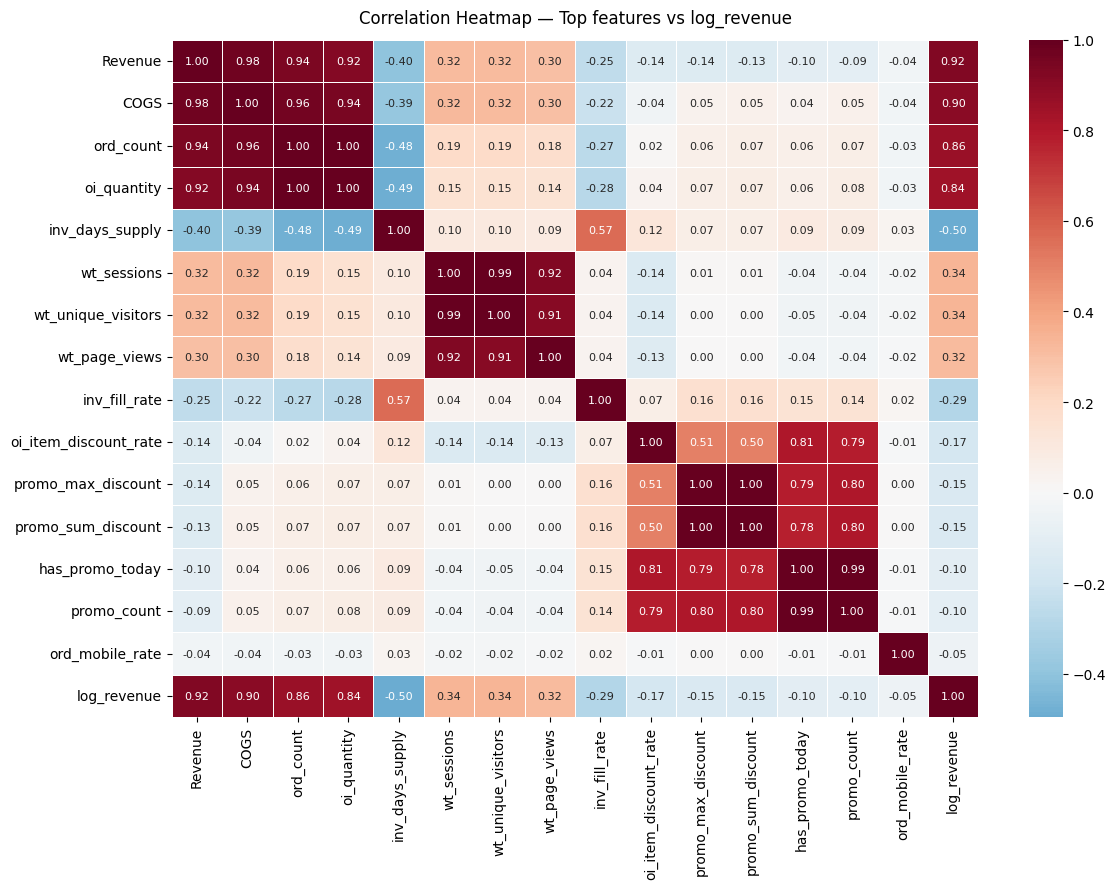

In [5]:
# ═══════════════════════════════════════════
# 4. CORRELATION HEATMAP → chọn feature engineering
# ═══════════════════════════════════════════
corr_df = master.copy()
corr_df['log_revenue'] = np.log1p(corr_df['Revenue'])

# Lấy các numeric cols có tương quan với log_revenue
num_cols = corr_df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = corr_df[num_cols].corr()['log_revenue'].drop('log_revenue').sort_values(key=abs, ascending=False)

print('Top 15 tương quan với log_revenue:')
print(corr_with_target.head(15).round(3).to_string())

# Heatmap ma trận tương quan (top 15 features)
top_corr_cols = corr_with_target.head(15).index.tolist() + ['log_revenue']
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_df[top_corr_cols].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Top features vs log_revenue', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

In [6]:
# ═══════════════════════════════════════════
# 5. FEATURE ENGINEERING

tet_map        = {y: pd.Timestamp(LunarDate(y, 1, 1).toSolarDate()) for y in range(2012, 2027)}
tet_dates_list = sorted(tet_map.values())
MEGA_SALE_DAYS = {(9,9),(10,10),(11,11),(12,12)}
mega_dates     = sorted([pd.Timestamp(year=y, month=m, day=d)
                         for y in range(2012, 2026) for m,d in MEGA_SALE_DAYS])
VN_FIXED_HOLIDAYS = {(1,1),(4,30),(5,1),(9,2)}

def days_to_next(date, events):
    future = [e for e in events if e >= date]
    return (future[0] - date).days if future else 999

def days_since_last(date, events):
    past = [e for e in events if e <= date]
    return (date - past[-1]).days if past else 999


def build_features(df, target='log_revenue'):
    df = df.sort_values('Date').reset_index(drop=True)

    # 1. Calendar
    df['dayofweek']      = df['Date'].dt.dayofweek
    df['month']          = df['Date'].dt.month
    df['day']            = df['Date'].dt.day
    df['dayofyear']      = df['Date'].dt.dayofyear
    df['quarter']        = df['Date'].dt.quarter
    df['is_weekend']     = (df['dayofweek'] >= 5).astype(int)
    df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
    df['is_vn_holiday']  = df['Date'].apply(lambda d: int((d.month, d.day) in VN_FIXED_HOLIDAYS))
    df['day_in_month_norm'] = df['day'] / df['Date'].dt.days_in_month

    # 2. Trend
    df['year_idx']    = (df['Date'] - TRAIN_START).dt.days / 365.25
    df['year_idx_sq'] = df['year_idx'] ** 2

    # 3. Event proximity
    df['days_to_tet']       = df['Date'].apply(lambda d: days_to_next(d, tet_dates_list)).clip(0, 60)
    df['days_since_tet']    = df['Date'].apply(lambda d: days_since_last(d, tet_dates_list)).clip(0, 60)
    df['is_pre_tet']        = (df['days_to_tet'] <= 14).astype(int)
    df['is_post_tet']       = (df['days_since_tet'] <= 7).astype(int)
    df['days_to_next_mega'] = df['Date'].apply(lambda d: days_to_next(d, mega_dates)).clip(0, 90)
    df['days_since_mega']   = df['Date'].apply(lambda d: days_since_last(d, mega_dates)).clip(0, 14)
    df['is_mega_sale']      = (df['days_to_next_mega'] == 0).astype(int)

    # 4. Lag 
    for lag in [1, 7, 364, 365]:                    
        df[f'rev_lag_{lag}'] = df[target].shift(lag)

    # 5. Rolling statistics (giảm bớt)
    s = df[target].shift(1)
    for w in [7, 30]:                                  # bỏ 14, 90
        df[f'rev_roll_mean_{w}'] = s.rolling(w).mean()
    df['rev_momentum_7_30'] = df['rev_roll_mean_7'] - df['rev_roll_mean_30']

    # 6. Fourier
    doy = df['Date'].dt.dayofyear
    for k in range(1, 4):
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

    # 7. Web traffic (lag1 + roll7 )
    for col in [c for c in df.columns if c.startswith('wt_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 8. Orders (lag1 + roll7)
    for col in [c for c in df.columns if c.startswith('ord_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 9. Promotions
    if 'promo_count' in df.columns:
        df['promo_intensity']  = df['promo_sum_discount'].fillna(0).clip(0, 500)
        df['promo_lag1_count'] = df['promo_count'].fillna(0).shift(1)
        df['promo_roll7']      = df['promo_count'].fillna(0).shift(1).rolling(7).mean()

    # 10. Interaction 
    if 'has_promo_today' in df.columns:
        df['weekend_x_promo'] = df['is_weekend'] * df['has_promo_today'].fillna(0)
        df['pretet_x_promo']  = df['is_pre_tet']  * df['has_promo_today'].fillna(0)

    # Dedup columns — phòng _lag1_lag1 nếu gọi lại trên df đã có derived cols
    df = df.loc[:, ~df.columns.duplicated()]

    return df

print('build_features() v3 ready')

build_features() v3 ready


In [7]:
# ═══════════════════════════════════════════
# 6. BUILD TRAINING DATASET
# ═══════════════════════════════════════════
df_full = master.copy()
df_full['log_revenue'] = np.log1p(df_full['Revenue'])
df_full['log_cogs']    = np.log1p(df_full['COGS'])
df_full = build_features(df_full, target='log_revenue')

# Fill NaN external
ext_fill = [c for c in df_full.columns
            if c.startswith(('wt_','ord_','oi_','promo_','inv_'))
            and not c.endswith(('_lag1','_lag3','_roll7'))]
for col in ext_fill:
    if df_full[col].isna().any():
        df_full[col] = df_full[col].ffill().fillna(df_full[col].median())

EXCLUDE      = {'Date','Revenue','COGS','log_revenue','log_cogs'}
SHORT_LAG_COLS = {'rev_lag_1','rev_lag_7',
                  'rev_roll_mean_7','rev_roll_mean_30','rev_momentum_7_30'}
FEATURE_COLS = [c for c in df_full.columns
                if c not in EXCLUDE and c not in SHORT_LAG_COLS]
df_train     = df_full.dropna(subset=FEATURE_COLS).copy()
X            = df_train[FEATURE_COLS].values
y_log_rev    = df_train['log_revenue'].values

#  COGS ratio 
_cogs_train = df_train[df_train['Revenue'] > 0].copy()
COGS_RATIO  = float((_cogs_train['COGS'] / _cogs_train['Revenue']).clip(0.01, 0.99).median())
print(f'COGS_RATIO = {COGS_RATIO:.4f}')

for lag_col in ['rev_lag_364', 'rev_lag_365']:
    if lag_col in df_full.columns:
        nan_before = df_full[lag_col].isna().sum()
        nan_after  = df_train[lag_col].isna().sum()
        print(f'{lag_col}: NaN trước dropna={nan_before}, sau dropna={nan_after}')

print(f'Train rows : {len(df_train)}')
print(f'Features   : {len(FEATURE_COLS)}')

COGS_RATIO = 0.8264
rev_lag_364: NaN trước dropna=364, sau dropna=0
rev_lag_365: NaN trước dropna=365, sau dropna=0
Train rows : 3468
Features   : 67


In [8]:
# ═══════════════════════════════════════════
# 7. BASELINE RIDGE
# ═══════════════════════════════════════════
split = int(len(X) * 0.8)
bl = Pipeline([('sc', StandardScaler()), ('r', Ridge(alpha=1.0, random_state=SEED))])
bl.fit(X[:split], y_log_rev[:split])
y_bl = np.expm1(bl.predict(X[split:]))
y_bt = np.expm1(y_log_rev[split:])
rmse_bl = np.sqrt(mean_squared_error(y_bt, y_bl))
print(f'Baseline Ridge | MAE={mean_absolute_error(y_bt, y_bl):,.0f} | RMSE={rmse_bl:,.0f} | R²={r2_score(y_bt, y_bl):.4f}')


Baseline Ridge | MAE=1,034,905 | RMSE=1,381,928 | R²=0.3113


In [9]:
# ═══════════════════════════════════════════
# 8. CROSS-VALIDATION 
BASE_PARAMS = {
    'objective':               'huber',
    'alpha':                   0.5,
    'n_estimators':            3000,
    'learning_rate':           0.02,
    'num_leaves':              47,       
    'max_depth':               6,         
    'min_child_samples':       50,        
    'min_gain_to_split':       0.02,    
    'subsample':               0.75,      
    'subsample_freq':          1,
    'colsample_bytree':        0.75,      
    'feature_fraction_bynode': 0.75,
    'reg_alpha':               0.3,      
    'reg_lambda':              4.0,       
    'random_state':            SEED,
    'n_jobs':                  -1,
    'verbose':                 -1,
}

tscv = TimeSeriesSplit(n_splits=5)
cv_mae, cv_rmse, best_iters_rev = [], [], []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
    cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

    m_rev = lgb.LGBMRegressor(**BASE_PARAMS)
    m_rev.fit(X[tr_idx], y_log_rev[tr_idx], eval_set=[(X[va_idx], y_log_rev[va_idx])], callbacks=cb)
    best_iters_rev.append(m_rev.best_iteration_)

    pred = np.expm1(m_rev.predict(X[va_idx]))
    true = np.expm1(y_log_rev[va_idx])
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    cv_mae.append(mae)
    cv_rmse.append(rmse)
    print(f'Fold {fold+1} | MAE={mae:>10,.0f} | RMSE={rmse:>10,.0f} | R²={r2:.4f} | iter={m_rev.best_iteration_}')

best_n_rev  = max(int(np.mean(best_iters_rev)),  50)
print(f'\nCV MAE : {np.mean(cv_mae):,.0f} ± {np.std(cv_mae):,.0f}')
print(f'CV RMSE: {np.mean(cv_rmse):,.0f} ± {np.std(cv_rmse):,.0f}')
print(f'best_n_rev={best_n_rev}')


Fold 1 | MAE=   647,124 | RMSE= 1,091,682 | R²=0.8667 | iter=583
Fold 2 | MAE=   397,259 | RMSE=   615,276 | R²=0.9495 | iter=747
Fold 3 | MAE=   379,085 | RMSE=   607,507 | R²=0.9525 | iter=485
Fold 4 | MAE=   336,176 | RMSE=   432,742 | R²=0.9374 | iter=687
Fold 5 | MAE=   292,911 | RMSE=   405,083 | R²=0.9324 | iter=628

CV MAE : 410,511 ± 123,697
CV RMSE: 630,458 ± 246,321
best_n_rev=626


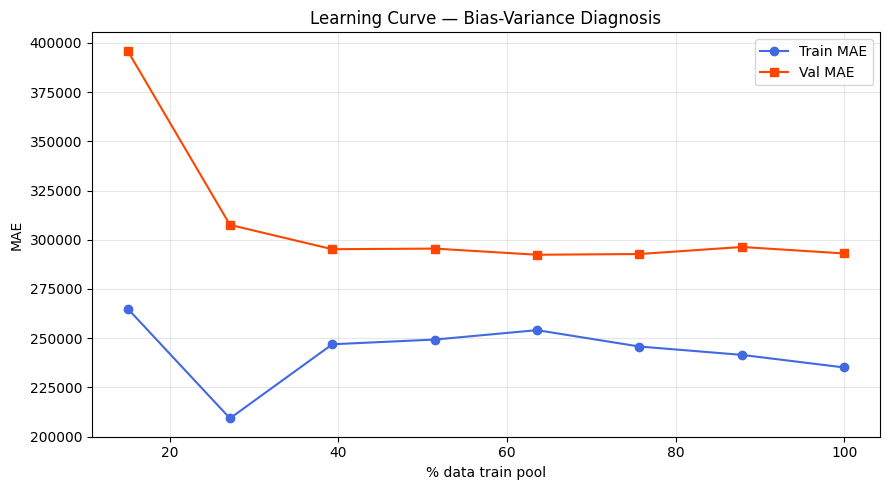

Train MAE: 235,129 | Val MAE: 293,059 | Gap: +57,930 (+24.6%)
 Bias-Variance ổn


In [10]:
# ═══════════════════════════════════════════
# 9. LEARNING CURVE
# ═══════════════════════════════════════════
tr_pool, val_idx_lc = list(tscv.split(X))[-1]
train_fracs = np.linspace(0.15, 1.0, 8)
train_errs, val_errs = [], []

for frac in train_fracs:
    n   = max(int(len(tr_pool) * frac), 60)
    m   = lgb.LGBMRegressor(**{**BASE_PARAMS, 'n_estimators': best_n_rev})
    m.fit(X[tr_pool[-n:]], y_log_rev[tr_pool[-n:]], callbacks=[lgb.log_evaluation(-1)])
    train_errs.append(mean_absolute_error(np.expm1(y_log_rev[tr_pool[-n:]]), np.expm1(m.predict(X[tr_pool[-n:]]))))
    val_errs.append(mean_absolute_error(np.expm1(y_log_rev[val_idx_lc]), np.expm1(m.predict(X[val_idx_lc]))))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_fracs*100, train_errs, 'o-', color='royalblue', label='Train MAE')
ax.plot(train_fracs*100, val_errs,   's-', color='orangered',  label='Val MAE')
ax.set_xlabel('% data train pool'); ax.set_ylabel('MAE')
ax.set_title('Learning Curve — Bias-Variance Diagnosis'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap       = val_errs[-1] - train_errs[-1]
gap_ratio = gap / train_errs[-1] if train_errs[-1] > 0 else 0
print(f'Train MAE: {train_errs[-1]:,.0f} | Val MAE: {val_errs[-1]:,.0f} | Gap: {gap:+,.0f} ({gap_ratio:+.1%})')
if gap_ratio > 0.30:
    print('⚠  Overfit → tăng reg_lambda / min_child_samples thêm')
else:
    print(' Bias-Variance ổn')

In [11]:
# ═══════════════════════════════════════════
# 10. OPTUNA HYPERPARAMETER TUNING
def objective(trial):
    params = {
        'objective':               'huber',
        'alpha':                    trial.suggest_float('alpha', 0.3, 0.7),
        'n_estimators':            3000,
        'learning_rate':            trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves':               trial.suggest_int('num_leaves', 31, 63),
        'max_depth':                trial.suggest_int('max_depth', 4, 7),
        'min_child_samples':        trial.suggest_int('min_child_samples', 40, 100),
        'min_gain_to_split':        trial.suggest_float('min_gain_to_split', 0.01, 0.1),
        'subsample':                trial.suggest_float('subsample', 0.6, 0.85),
        'subsample_freq':           1,
        'colsample_bytree':         trial.suggest_float('colsample_bytree', 0.6, 0.85),
        'feature_fraction_bynode':  trial.suggest_float('feature_fraction_bynode', 0.6, 0.85),
        'reg_alpha':                trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
        'reg_lambda':               trial.suggest_float('reg_lambda', 2.0, 15.0, log=True),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    }
    all_splits = list(TimeSeriesSplit(n_splits=5).split(X))
    scores = []
    for tr, va in all_splits[-3:]:
        m = lgb.LGBMRegressor(**params)
        m.fit(X[tr], y_log_rev[tr], eval_set=[(X[va], y_log_rev[va])],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
        scores.append(mean_absolute_error(np.expm1(y_log_rev[va]), np.expm1(m.predict(X[va]))))
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS = {**BASE_PARAMS, **study.best_params}
print(f'Best CV MAE: {study.best_value:,.0f}')
print('Best params:', study.best_params)

# ── Recalibrate best_n_rev với BEST_PARAMS
_recal_iters = []
for tr_idx, va_idx in list(TimeSeriesSplit(n_splits=5).split(X))[-3:]:
    _m = lgb.LGBMRegressor(**{**BEST_PARAMS, 'n_estimators': 3000})
    _m.fit(X[tr_idx], y_log_rev[tr_idx],
           eval_set=[(X[va_idx], y_log_rev[va_idx])],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    _recal_iters.append(_m.best_iteration_)
best_n_rev = max(int(np.mean(_recal_iters)), 50)
BEST_PARAMS['n_estimators'] = best_n_rev
print(f'best_n_rev (recalibrated) = {best_n_rev}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV MAE: 333,755
Best params: {'alpha': 0.6024002596017098, 'learning_rate': 0.020069813356348498, 'num_leaves': 46, 'max_depth': 4, 'min_child_samples': 50, 'min_gain_to_split': 0.017576778010791518, 'subsample': 0.6794313521719242, 'colsample_bytree': 0.735698653405048, 'feature_fraction_bynode': 0.7696537738681272, 'reg_alpha': 0.3439801991584819, 'reg_lambda': 7.751156451007876}
best_n_rev (recalibrated) = 738


In [12]:
# ═══════════════════════════════════════════
# 11. FINAL MODEL
# ═══════════════════════════════════════════
tscv = TimeSeriesSplit(n_splits=5)

final_rev = lgb.LGBMRegressor(**BEST_PARAMS)
final_rev.fit(X, y_log_rev, callbacks=[lgb.log_evaluation(-1)])

# Bias correction từ trung bình 3 fold cuối
_last_tr_idx, _last_va_idx = list(tscv.split(X))[-1]
bias_list = []
for tr_idx, va_idx in list(tscv.split(X))[-3:]:
    tmp = lgb.LGBMRegressor(**BEST_PARAMS)
    tmp.fit(X[tr_idx], y_log_rev[tr_idx], callbacks=[lgb.log_evaluation(-1)])
    _vp = np.expm1(tmp.predict(X[va_idx]))
    _vt = np.expm1(y_log_rev[va_idx])
    bias_list.append(float((_vt - _vp).mean()))

# Validation trên fold cuối (dùng _last_va_idx đã lưu ở trên)
val_pred = np.expm1(final_rev.predict(X[_last_va_idx]))
val_true = np.expm1(y_log_rev[_last_va_idx])
# Lưu val_dates để dùng lại ở cell SHAP plot (tránh lệch index)
val_dates_final = df_train.iloc[_last_va_idx]['Date']

BIAS_CORRECTION = float(np.mean(bias_list))

val_mae  = mean_absolute_error(val_true, val_pred)
val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
val_r2   = r2_score(val_true, val_pred)

print(f'BIAS_CORRECTION per fold: {[f"{b:+,.0f}" for b in bias_list]}')
print(f'Val | MAE={val_mae:,.0f} | RMSE={val_rmse:,.0f} | R²={val_r2:.4f}')
print(f'BIAS_CORRECTION = {BIAS_CORRECTION:+,.0f}')
print(' Retrain done')


BIAS_CORRECTION per fold: ['+115,013', '+154,814', '+225,668']
Val | MAE=174,430 | RMSE=235,723 | R²=0.9771
BIAS_CORRECTION = +165,165
 Retrain done


In [13]:
# ═══════════════════════════════════════════
# 12. RECURSIVE FORECASTING
# ═══════════════════════════════════════════
test_dates_df = sample_sub[['Date']].assign(Revenue=np.nan, COGS=np.nan)
master_full   = pd.concat([master, test_dates_df]).sort_values('Date').reset_index(drop=True)

ext_cols = [c for c in master_full.columns if c.startswith(('wt_','ord_','oi_'))]
for col in ext_cols:
    fill_val = master_full.loc[master_full['Date'] <= TRAIN_END, col].dropna().tail(90).mean()
    master_full[col] = master_full[col].ffill().fillna(fill_val)

if promo_daily is not None:
    promo_cols = [c for c in promo_daily.columns if c != 'Date']
    master_full = master_full.drop(columns=[c for c in promo_cols if c in master_full.columns], errors='ignore')
    master_full = master_full.merge(promo_daily, on='Date', how='left').fillna({c: 0 for c in promo_cols})

master_full['log_revenue'] = np.log1p(master_full['Revenue'].fillna(0))
master_full['log_cogs']    = np.log1p(master_full['COGS'].fillna(0))

# Pre-compute static features (calendar, Tet, Mega, Fourier) một lần — tránh .apply() lặp lại
def build_static_features(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['dayofweek']         = df['Date'].dt.dayofweek
    df['month']             = df['Date'].dt.month
    df['day']               = df['Date'].dt.day
    df['dayofyear']         = df['Date'].dt.dayofyear
    df['quarter']           = df['Date'].dt.quarter
    df['is_weekend']        = (df['dayofweek'] >= 5).astype(int)
    df['is_month_end']      = df['Date'].dt.is_month_end.astype(int)
    df['is_vn_holiday']     = df['Date'].apply(lambda d: int((d.month, d.day) in VN_FIXED_HOLIDAYS))
    df['day_in_month_norm'] = df['day'] / df['Date'].dt.days_in_month
    df['year_idx']          = (df['Date'] - TRAIN_START).dt.days / 365.25
    df['year_idx_sq']       = df['year_idx'] ** 2
    df['days_to_tet']       = df['Date'].apply(lambda d: days_to_next(d, tet_dates_list)).clip(0, 60)
    df['days_since_tet']    = df['Date'].apply(lambda d: days_since_last(d, tet_dates_list)).clip(0, 60)
    df['is_pre_tet']        = (df['days_to_tet'] <= 14).astype(int)
    df['is_post_tet']       = (df['days_since_tet'] <= 7).astype(int)
    df['days_to_next_mega'] = df['Date'].apply(lambda d: days_to_next(d, mega_dates)).clip(0, 90)
    df['days_since_mega']   = df['Date'].apply(lambda d: days_since_last(d, mega_dates)).clip(0, 14)
    df['is_mega_sale']      = (df['days_to_next_mega'] == 0).astype(int)
    doy = df['Date'].dt.dayofyear
    for k in range(1, 4):
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    if 'has_promo_today' in df.columns:
        df['weekend_x_promo'] = df['is_weekend'] * df['has_promo_today'].fillna(0)
        df['pretet_x_promo']  = df['is_pre_tet']  * df['has_promo_today'].fillna(0)
    if 'promo_count' in df.columns:
        df['promo_intensity']  = df['promo_sum_discount'].fillna(0).clip(0, 500)
        df['promo_lag1_count'] = df['promo_count'].fillna(0).shift(1)
        df['promo_roll7']      = df['promo_count'].fillna(0).shift(1).rolling(7).mean()
    return df

master_full = build_static_features(master_full)

predictions = []

for date in sample_sub['Date'].tolist():
    row_i = master_full.index[master_full['Date'] == date][0]
    # Dùng index pd.Timestamp để tránh type mismatch với numpy datetime64
    known_log = master_full.set_index('Date')['log_revenue']

    row = master_full.loc[[row_i]].copy()

    # Lag features
    for lag in [1, 7, 364, 365]:
        lag_date = date - pd.Timedelta(days=lag)
        row[f'rev_lag_{lag}'] = known_log.get(lag_date, np.nan)

    # Rolling mean từ history
    hist_series = known_log[known_log.index < date].dropna()
    row['rev_roll_mean_7']   = hist_series.tail(7).mean()  if len(hist_series) >= 1 else np.nan
    row['rev_roll_mean_30']  = hist_series.tail(30).mean() if len(hist_series) >= 1 else np.nan
    row['rev_momentum_7_30'] = row['rev_roll_mean_7'].values[0] - row['rev_roll_mean_30'].values[0]

    # Web traffic / orders lag+roll
    for col in [c for c in master_full.columns
                if c.startswith(('wt_','ord_')) and not c.endswith(('_lag1','_roll7'))]:
        prev = master_full.loc[master_full['Date'] < date, col].dropna()
        if f'{col}_lag1' in FEATURE_COLS:
            row[f'{col}_lag1']  = prev.iloc[-1] if len(prev) > 0 else 0.0
        if f'{col}_roll7' in FEATURE_COLS:
            row[f'{col}_roll7'] = prev.tail(7).mean() if len(prev) > 0 else 0.0

    feat    = row[FEATURE_COLS].copy()
    log_rev = float(final_rev.predict(feat)[0])
    rev     = max(np.expm1(log_rev) + BIAS_CORRECTION, 0.0)
    cogs    = rev * COGS_RATIO
    predictions.append({'Date': date, 'Revenue': rev, 'COGS': cogs})

    # Cập nhật log_revenue cho ngày vừa predict
    master_full.loc[row_i, 'log_revenue'] = log_rev

pred_df = pd.DataFrame(predictions)
print(f'Forecast done: {len(pred_df)} ngày')
print(f'Revenue  min/max: {pred_df["Revenue"].min():,.0f} / {pred_df["Revenue"].max():,.0f}')

Forecast done: 548 ngày
Revenue  min/max: 2,383,981 / 3,006,171


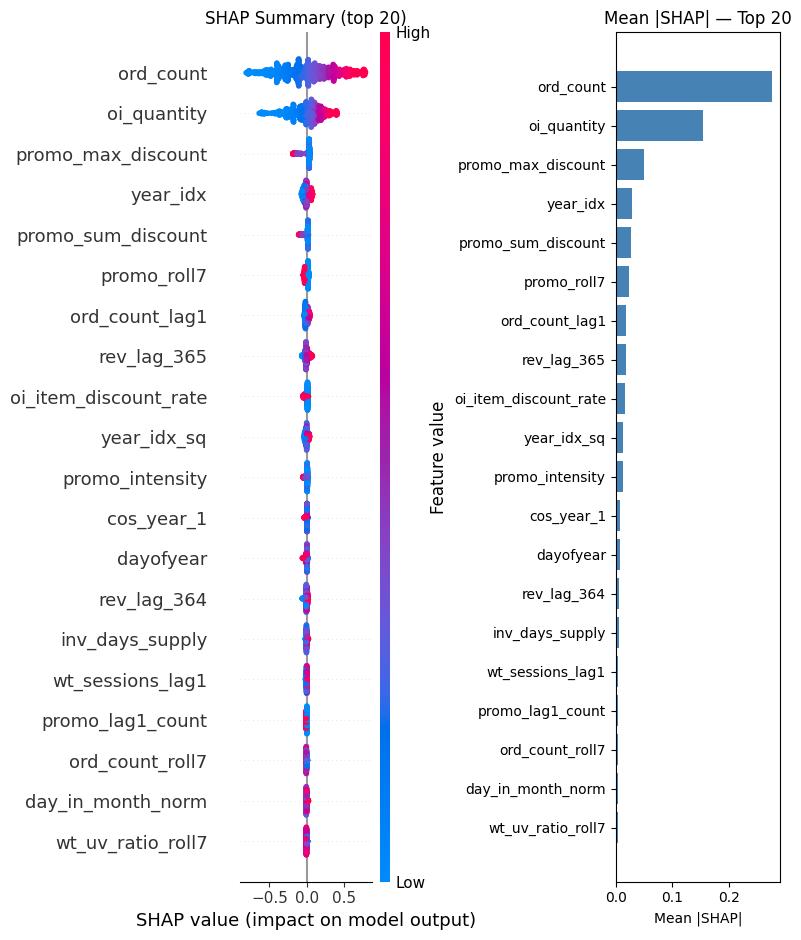

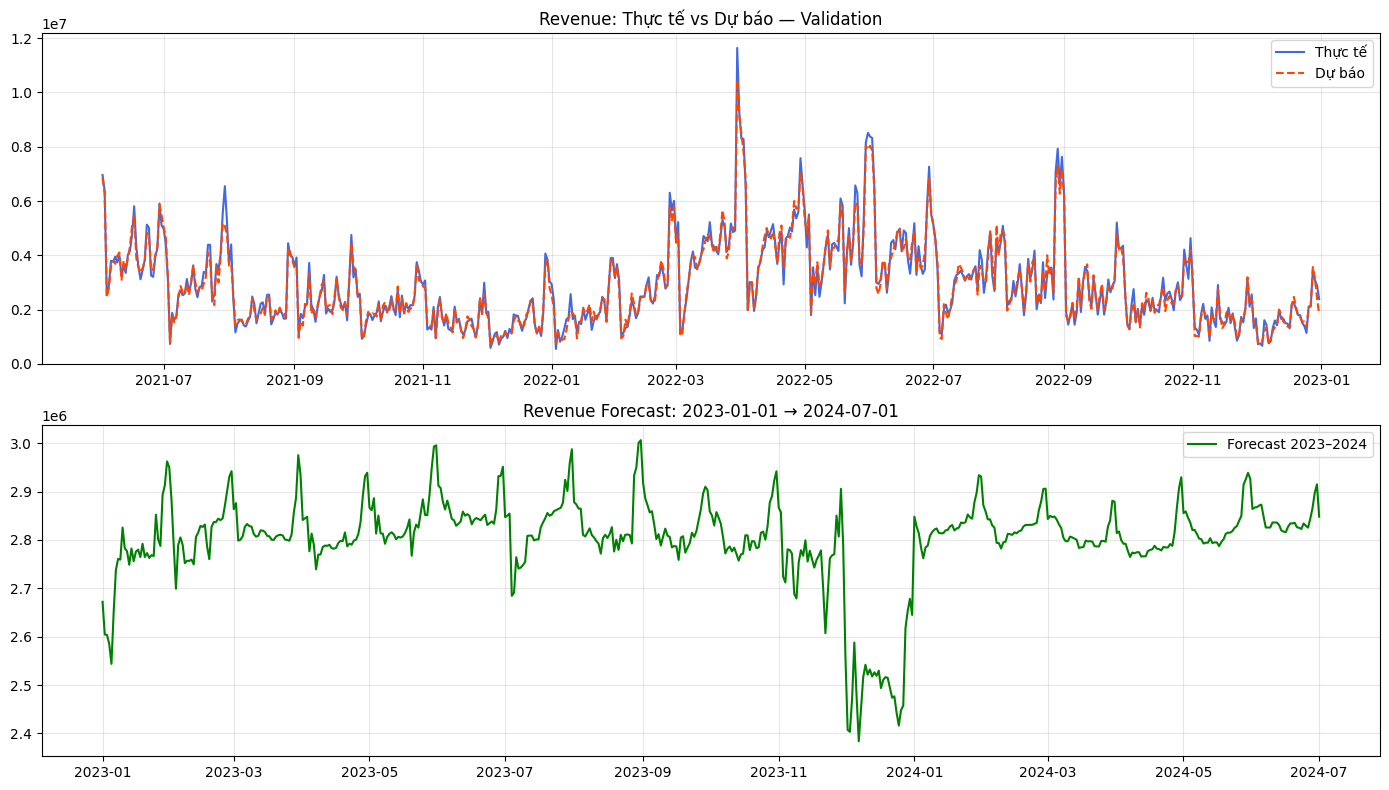

In [14]:
# ═══════════════════════════════════════════
# 13. SHAP + VALIDATION PLOTS
# ═══════════════════════════════════════════
sample_idx = np.sort(np.random.choice(len(df_train), min(1000, len(df_train)), replace=False))
explainer  = shap.TreeExplainer(final_rev)
shap_vals  = explainer(df_train.iloc[sample_idx][FEATURE_COLS])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0])
shap.summary_plot(shap_vals, df_train.iloc[sample_idx][FEATURE_COLS], show=False, max_display=20)
axes[0].set_title('SHAP Summary (top 20)')

mean_shap = pd.Series(np.abs(shap_vals.values).mean(0), index=FEATURE_COLS).sort_values(ascending=False)
top20 = mean_shap.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[1].set_title('Mean |SHAP| — Top 20')
axes[1].set_xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()


# Dùng val_dates_final đã được lưu ở cell 11 (khớp với val_pred/val_true)
val_dates = val_dates_final
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(val_dates.values, val_true, label='Thực tế', color='royalblue', lw=1.5)
axes[0].plot(val_dates.values, val_pred, label='Dự báo',  color='orangered',  lw=1.5, ls='--')
axes[0].set_title('Revenue: Thực tế vs Dự báo — Validation'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(pred_df['Date'], pred_df['Revenue'], color='green', lw=1.5, label='Forecast 2023–2024')
axes[1].set_title('Revenue Forecast: 2023-01-01 → 2024-07-01'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════
# 14. SUBMISSION
# ═══════════════════════════════════════════
submission = sample_sub[['Date']].merge(pred_df, on='Date', how='left')
assert len(submission) == len(sample_sub),      '❌ Số dòng không khớp'
assert submission['Revenue'].isna().sum() == 0, '❌ Thiếu Revenue'
assert submission['COGS'].isna().sum() == 0,    '❌ Thiếu COGS'

submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission[['Date','Revenue','COGS']].to_csv('submission.csv', index=False)
print('=== submission.csv saved ===')
print(submission.head(5).to_string(index=False))

=== submission.csv saved ===
      Date      Revenue         COGS
2023-01-01 2.672084e+06 2.208133e+06
2023-01-02 2.604463e+06 2.152252e+06
2023-01-03 2.603758e+06 2.151670e+06
2023-01-04 2.584869e+06 2.136061e+06
2023-01-05 2.543845e+06 2.102160e+06
